## Script to find ROIs in muscle imaging data by PCA + NMF

Images too big for PCA, so will interatively cut sections off and run PCA + NMF
NMF works great to separate rois with large spatial overlap in both space and time. It doesn't produce binary ROIs though

Original dataset collected by Leandre Dubois (and Victor Stimpfling)



In [1]:
import cv2
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
from sklearn.decomposition import PCA


In [2]:
pupa_num = 1  # set pupa number (1, 2, etc.)
hz = 40

In [3]:
# get list of recordings sorted by number 
# (recoring# is not zero-padded in the folder names)
main_path = '/mnt/upramdya_data/MA/Development_project/LD'
pupa_path = os.path.join(main_path, f'pupa_{pupa_num}')
recording_list = os.listdir(pupa_path)

# remove any non-recording files
recording_list = [f for f in recording_list if 'recording' in f]

def extract_recording_number(filename):
    # 1. Remove the 'recording' prefix
    part_after_prefix = filename.split('recording', 1)[1]
    # 2. Extract the number up to the next underscore
    number_string = part_after_prefix.split('_', 1)[0]
    # 3. Convert the extracted string to an integer
    return int(number_string)

recording_list.sort(key=extract_recording_number)

In [4]:
# get last recording folder (most active) and get average image to mask from
recording = recording_list[-1]
recording_path = os.path.join(pupa_path, recording)

h5_file = os.path.join(recording_path, 'video_raw.h5')

# get average image of first 100 frames
with h5py.File(h5_file, 'r') as f:
    # Access the data you need from the HDF5 file
    frames = f['frames'][:]
    ave = np.mean(frames[0:100], axis=0)


(493.0, 793.0)

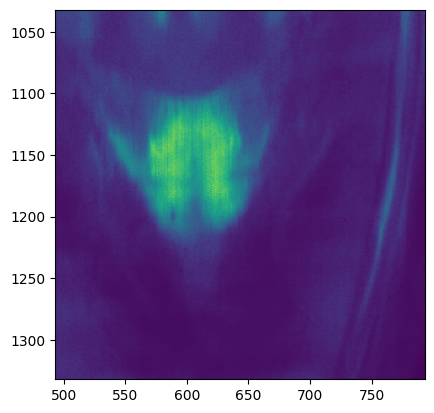

In [5]:
plt.imshow(ave)
h1 = 300
w1 = 300
x1 = 343 + 150
y1 = 132 + 900
plt.ylim(y1 + h1, y1)
plt.xlim(x1, x1 + w1)

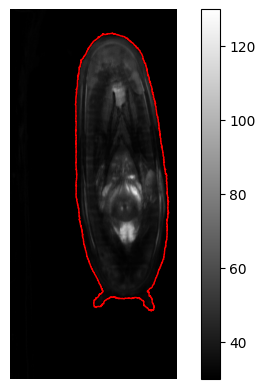

In [6]:
# mask to keep only the pupa

# threshold
thresh = 30
mask = (ave > thresh).astype(np.uint8) * 255

# find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# keep largest contour
contour = max(contours, key=cv2.contourArea)

# plot
plt.figure()
plt.imshow(ave, cmap='gray', vmin=30, vmax=130)
plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=1)
plt.axis('off')
plt.colorbar()
plt.show()

In [7]:
# get the bounding box of the contour (to only keep area for PCA)
x, y, w, h = cv2.boundingRect(contour)
print(f"Bounding box: x_0={x}, y_0={y}, width={w}, height={h}")

Bounding box: x_0=339, y_0=124, width=486, height=1443


(489.0, 789.0)

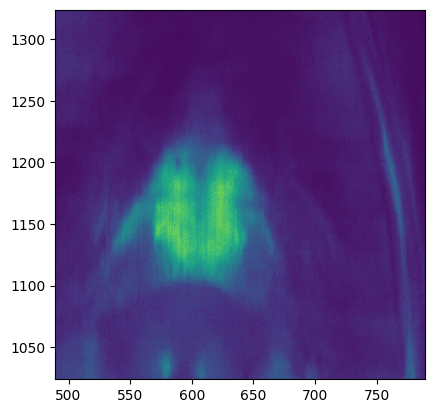

In [8]:
plt.imshow(ave)
h1 = 300
w1 = 300
x1 = x + 150
y1 = y + 900
plt.ylim(y1, y1 + h1)
plt.xlim(x1, x1 + w1)

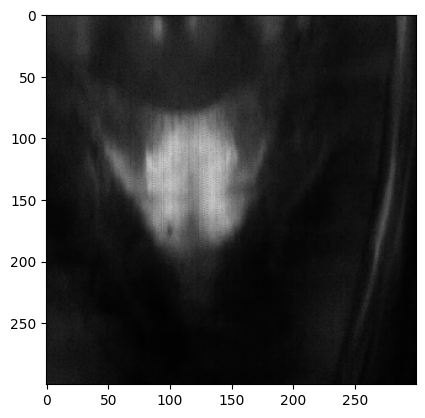

(4799, 90000)


In [9]:
# SELECT ONE AREA FOR PCA TESTING

SAVE_NAME = 'TEST_section'

h1 = 250
w_max = 500
if w > w_max:
    assert ("ERROR: Width of bounding box is greater than max width for PCA area.")
    error
w1 = w
x1 = x
y1 = y + 900

h1 = 300
w1 = 300
x1 = x + 150
y1 = y + 900

area1 = ave[y1:y1+h1, x1:x1+w1]
plt.figure()
plt.imshow(area1, cmap='gray', vmin=30, vmax=130)
plt.show()

# mask frames to only keep area for PCA
frames_masked = frames[:, y1:y1+h1, x1:x1+w1]

# Flatten frames for PCA
num_frames = frames_masked.shape[0]
frames_flat = frames_masked.reshape(num_frames, -1)
print(frames_flat.shape) # MAX for computer about 140'000 pixels

In [10]:
# Initialize PCA and fit to the data
# try to load if it exists first (and save if not) - TAKES A LONG TIME!
pca_save_path = os.path.join(recording_path, f'pca_{SAVE_NAME}.pkl')
try:
    pca = pickle.load(open(pca_save_path, 'rb'))
    print('PCA loaded')
except:
    pca = PCA()
    pca.fit(frames_flat)
    pickle.dump(pca, open(pca_save_path, 'wb'))

PCA loaded


In [11]:
# Transform the data into principal components - get Scores for each PC (shape = n_pc x timepoints)
pca_scores = pca.transform(frames_flat)

# get principal components Loadings for each PC (shape = n_pc x n_pixels)
pca_loadings = pca.components_

# get explained variance ratio (shape = n_pc)
explained_variance = pca.explained_variance_ratio_

# get eigenvalues, scaling factor for each PC (shape = n_pc)
eigenvalues = pca.singular_values_

print(f"SHAPES: scores {pca_scores.shape}, loadings {pca_loadings.shape}, explained variance {explained_variance.shape}, eigenvalues {eigenvalues.shape}")

SHAPES: scores (4799, 4799), loadings (4799, 90000), explained variance (4799,), eigenvalues (4799,)


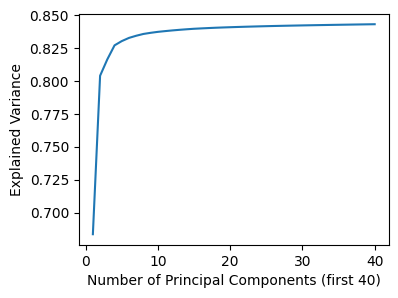

In [12]:
plt.figure(figsize=(4, 3))  
n = 40
plt.plot(np.array(range(n)) + 1, np.cumsum(explained_variance[0:n]))
plt.xlabel(f'Number of Principal Components (first {n})')
plt.ylabel('Explained Variance')

# save figure
save_path = os.path.join(recording_path, f'PCA_{SAVE_NAME}_explained_variance.png')
plt.savefig(save_path)

plt.show()



In [13]:
# Get the first few components loadings (for visualization)
num_components = 9
principal_components_n = pca_loadings[:num_components]  # Shape (num_components, n_pixels)

# Reconstruct components into 2D
reconstructed_components = []
for component in principal_components_n:
    component_2d = component.reshape(h1, w1)
    reconstructed_components.append(component_2d)

# Convert to NumPy array for easier handling (shape: num_components, width, height)
reconstructed_components = np.array(reconstructed_components)

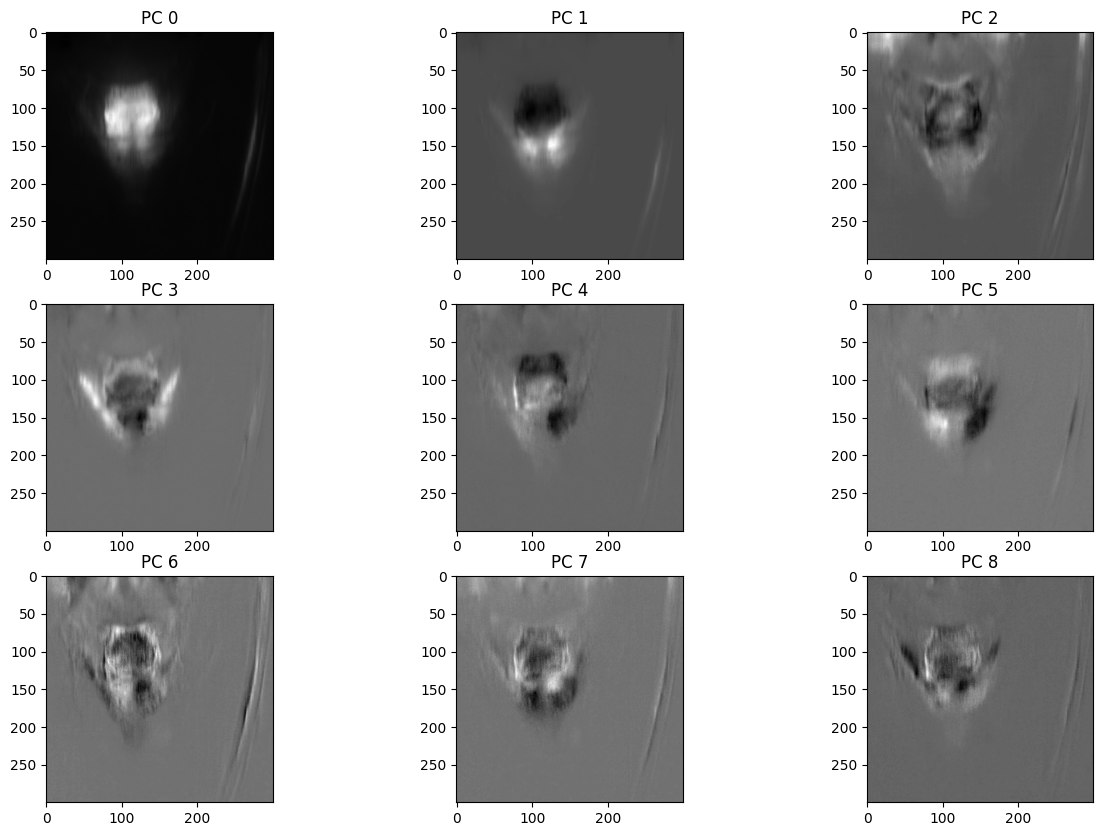

In [14]:
# plot top component loadings
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i in range(num_components):
    axes[i].imshow(reconstructed_components[i], cmap='gray')
    axes[i].set_title(f'PC {i}')

# save figure
save_path = os.path.join(recording_path, f'first_9_PCs_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

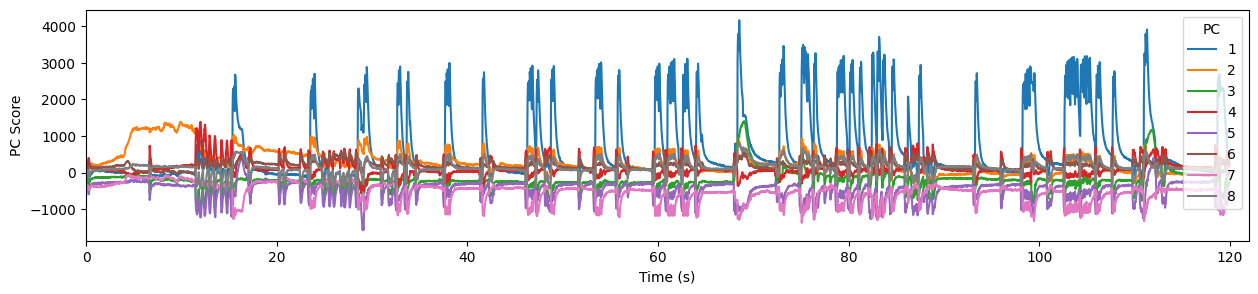

In [15]:
# plot scores for first few components in time
t = np.arange(pca_scores.shape[0])/hz
plt.figure(figsize=(15, 3))

plt.plot(t, pca_scores[:,1:9])
plt.legend(range(1, 9), title='PC', loc='upper right')
    
plt.xlabel('Time (s)')
plt.ylabel('PC Score')
plt.xlim(0, max(t)+2)

# save figure
save_path = os.path.join(recording_path, f'first_9_PCs_in_time_TEST_section.png')
plt.savefig(save_path)

plt.show()

(6.0, 20.0)

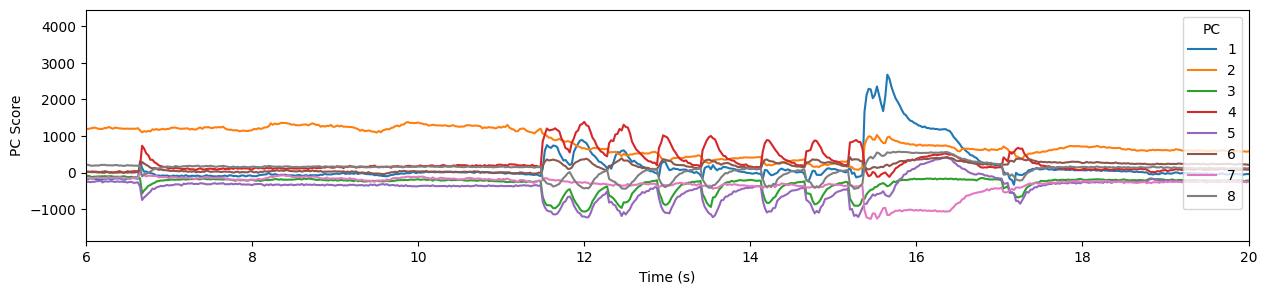

In [16]:
t = np.arange(pca_scores.shape[0])/hz
plt.figure(figsize=(15, 3))

plt.plot(t, pca_scores[:,1:9])
plt.legend(range(1, 9), title='PC', loc='upper right')
    
plt.xlabel('Time (s)')
plt.ylabel('PC Score')
plt.xlim([6,20])

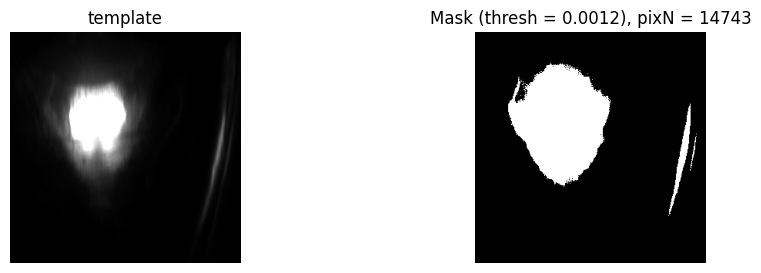

N of pixels = 14743 - should be less than 40000


In [17]:
# Get new mask from first component
# (otherwise there are too many pixels selected, first component is mostly noise vs active pixels)
thresh = 0.0012
template = reconstructed_components[0]
mask_new = template >= thresh

# flatten mask (to convert from mask to mask_new)
mask_flat = mask_new.flatten()


# plot raw and mask
_, axes = plt.subplots(1, 2, figsize=(11, 3))
im = axes[0].imshow(template, cmap='gray')
im.set_clim(0, 0.01)
axes[1].imshow(mask_new, cmap='gray')
axes[0].set_title('template')
axes[1].set_title(f'Mask (thresh = {thresh}), pixN = {sum(mask_flat)}')
axes[0].axis('off')  # Hide axis
axes[1].axis('off')  # Hide axis

# save figure
save_path = os.path.join(recording_path, f'Template_and_new_mask_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

print(f"N of pixels = {sum(mask_flat)} - should be less than 40000")
assert sum(mask_flat) < 40000, f"Mask has too many pixels ({sum(mask_flat)}) - increase threshold"

In [18]:
# keep only pixels in mask out of principal components
pca_loadings_masked = pca_loadings[:, mask_flat]

In [19]:
# Cluster pixels based on their loadings for the first N components

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
import colorcet as cc

n_pcs = 20
n_clusters = 5
n_px = frames_flat.shape[1]

# try to load if it exists first (and save if not) - TAKES A LONG TIME!
clusters_save_path = os.path.join(recording_path, f'clusters_{n_pcs}pcs_{n_clusters}clust_{SAVE_NAME}.pkl')# Cluster pixels based on their loadings for the first N components

try:
    clusters = pickle.load(open(clusters_save_path, 'rb'))
    print('clusters loaded')
except:
    print('clustering...')
    data = pca_loadings_masked[:n_pcs,:n_px].T

    # Compute pairwise correlation matrix (data points x data points)
    correlation_matrix = np.corrcoef(data)
    del data

    # Condense the distance matrix (1-correlation) (required by some clustering algorithms)
    condensed_distance = squareform(1 - correlation_matrix, checks=False)
    del correlation_matrix

    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_distance, method='average')
    del condensed_distance

    # Extract clusters (e.g., form 3 clusters)
    clusters = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
    del linkage_matrix

    # save
    print('saving clusters...')
    pickle.dump(clusters, open(clusters_save_path, 'wb'))
    

clusters loaded


In [20]:
## function to plot the cluster locations
from matplotlib.colors import ListedColormap

def show_clusters(clusters, mask, title='Clusters', save_path=None):

    # check that the clusters match the mask
    assert len(clusters) == mask.sum(), f"Mask and clusters do not match: {len(clusters)} != {mask.sum()}"

    # get the number of clusters
    n_clusters = len(np.unique(clusters))

    # reconstruct the clusters into 2D using the mask
    reconstructed = np.zeros(mask.shape)
    reconstructed[mask] = clusters

    # Create a color palette with `n_clusters` colors, add black as the first color
    clrs = list(cc.glasbey[:n_clusters])  # Use glasbey palette
    clrs = [(0, 0, 0)] + clrs  # Add black as the first color
    custom_cmap = ListedColormap(clrs)

    # plot
    plt.figure(figsize=(12, 6))
    plt.imshow(reconstructed, cmap=custom_cmap)
    plt.title(title)
    plt.colorbar(ticks=range(n_clusters+1))

    # set xlim and ylim based on the mask
    miny, maxy = np.where(mask)[0].min(), np.where(mask)[0].max()
    minx, maxx = np.where(mask)[1].min(), np.where(mask)[1].max()
    plt.ylim(miny, maxy)
    plt.xlim(minx, maxx)
    plt.gca().invert_yaxis()

    # save figure
    if save_path:
        plt.savefig(save_path)
    
    plt.show()

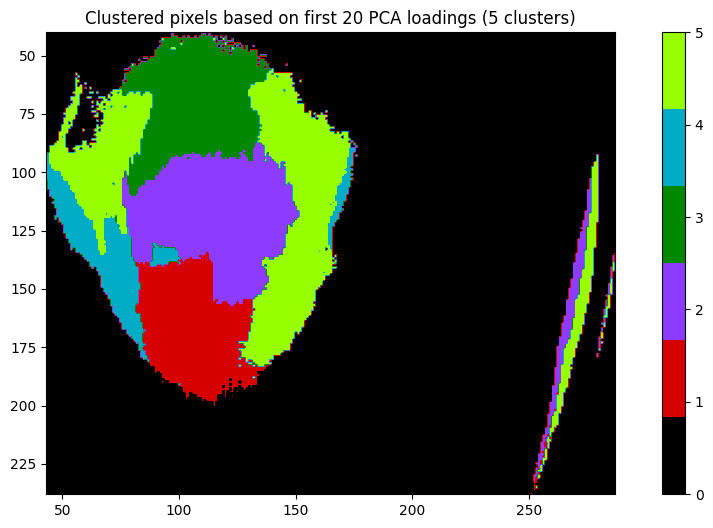

In [21]:
save_path = os.path.join(recording_path, f'All_clusters_space_{SAVE_NAME}.png')
show_clusters(clusters, mask_new, title=f'Clustered pixels based on first {n_pcs} PCA loadings ({n_clusters} clusters)', save_path=save_path)


In [22]:
## function to plot the cluster fluorescence over time
def plot_cluster_fluo(data, hz, clusters, mask, title='', save_path=None, xlim=None):

    # flatten the mask
    mask_flat = mask.flatten()

    # check that the mask has the same shape as the data
    assert mask_flat.shape[0] == data.shape[1], f"Mask shape {mask_flat.shape} does not match data {data.shape}"

    # check that the clusters shape match the masked data
    assert len(clusters) == np.sum(mask), f"Clusters pixels {len(clusters)} do not match mask {np.sum(mask)}"

    # get the time dimension
    t = np.arange(data.shape[0])/hz

    # get the number of clusters
    n_clusters = len(np.unique(clusters))

    # Create a color palette with `n_clusters` colors to match cluster plot colors
    clrs = list(cc.glasbey[:n_clusters])  # Use glasbey palette

    # get scores for clusters in time
    clusters_time = np.zeros((data.shape[0], n_clusters))
    for c in range(1, n_clusters+1):
        clusters_time[:,c-1] = np.mean(data[:,mask_flat][:,clusters == c], axis=1)

    # plot
    n = 5 # number of clusters per plot
    subplot_num = n_clusters // n 
    if subplot_num == 0:
        subplot_num = 1
    _, axes = plt.subplots(subplot_num, 1, figsize=(15, 2.5*subplot_num))
    if subplot_num <= 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        for j in range(n):
            if n*i + j >= n_clusters:
                break
            ax.plot(t, clusters_time[:, n * i + j], color=clrs[n * i + j])
        ax.legend(range(n*i+1, n*(i+1)+1), loc='upper left', title='Cluster #', bbox_to_anchor=(1, 1))
            
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Fluorescence')
        if xlim:
            ax.set_xlim(xlim)
        else:
            ax.set_xlim([0, t[-1]])
        
    axes[0].set_title(title)

    # save figure
    if save_path:
        plt.savefig(save_path)

    plt.show()
       

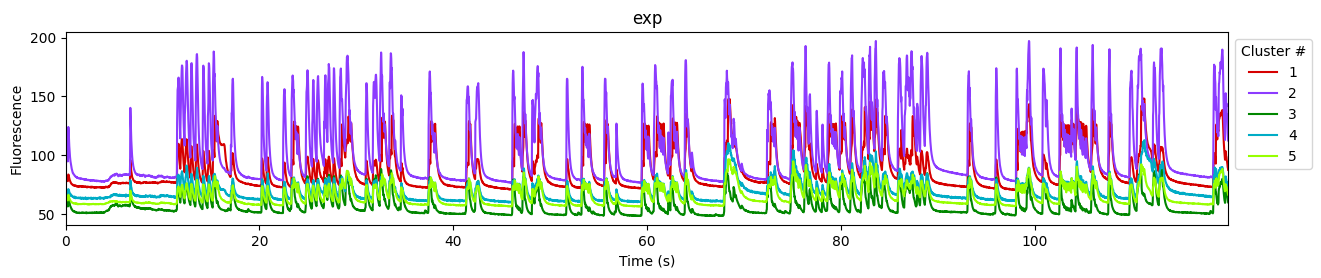

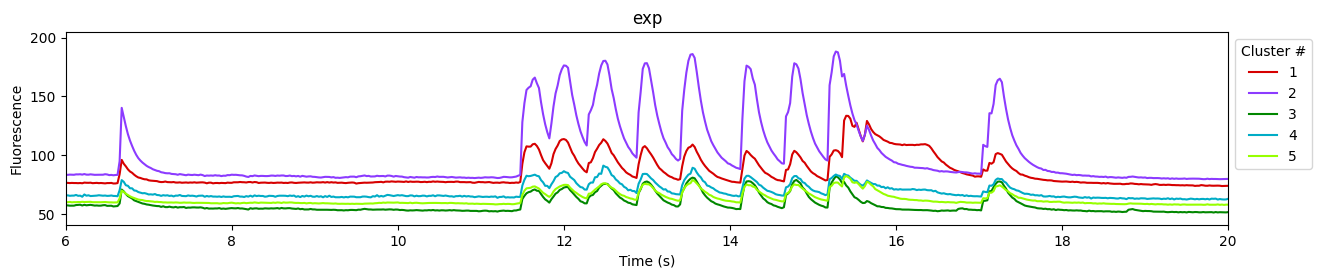

In [ ]:
save_path = os.path.join(recording_path, f'All_clusters_time_{SAVE_NAME}.png')
plot_cluster_fluo(frames_flat, hz, clusters, mask_new, title='exp', save_path=save_path)
plot_cluster_fluo(frames_flat, hz, clusters, mask_new, title='exp', save_path='', xlim=[6,20])

## TRY NMF TO SEPARATE OVERLAPPING, NON-GAUSSIAN MUSCLES


In [ ]:
from sklearn.decomposition import FastICA

# reshape frames_flat: pixels × time
Y, X = frames_masked.shape[1:]
Xmat = frames_masked.reshape(frames_masked.shape[0], -1).T  # (pixels, time)

# PCA first (keep K components)
K = 20
X_pca = PCA(n_components=K, whiten=True).fit_transform(Xmat)

# ICA
ica = FastICA(n_components=K, max_iter=1000)
S = ica.fit_transform(X_pca)   # spatial maps (pixels × components)
A = ica.mixing_                # timecourses (components × time)

# reshape spatial maps
spatial_maps = S.reshape(Y, X, K)


# TESTING


In [ ]:
spatial_maps.shape

(300, 300, 20)

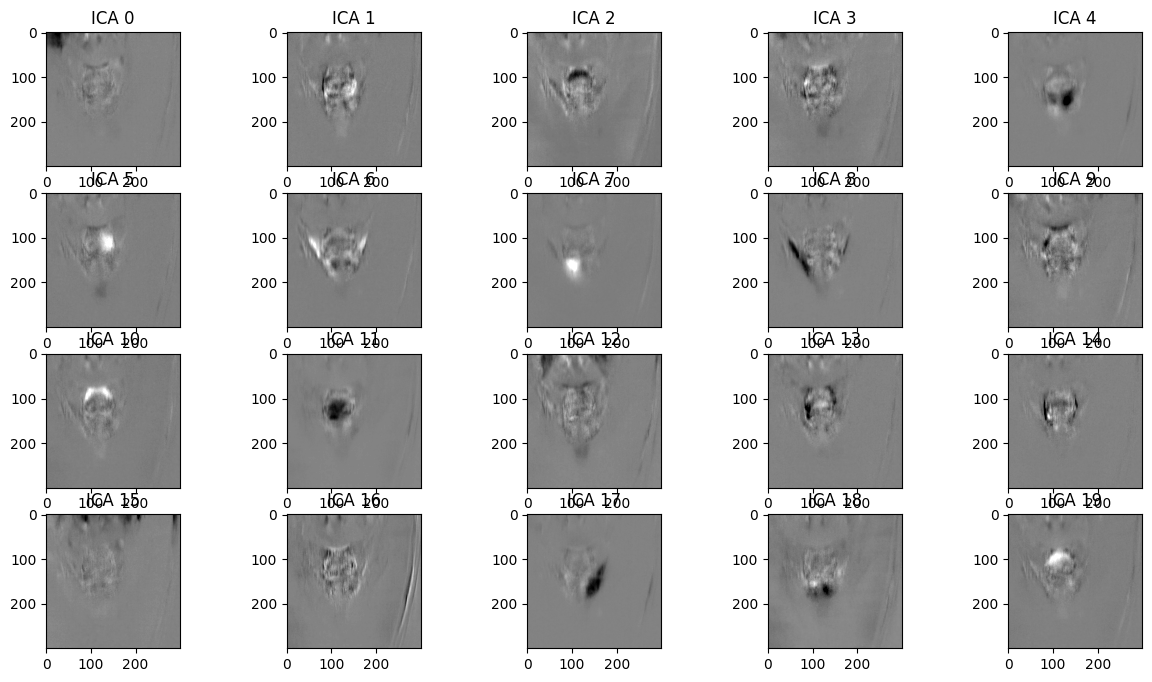

In [ ]:
# plot top components
num_components = K
fig, axes = plt.subplots(4, 5, figsize=(15, 8))
axes = axes.flatten()
for i in range(min(num_components, len(axes))):
    axes[i].imshow(spatial_maps[:,:,i], cmap='gray', vmin=-10, vmax=10)
    axes[i].set_title(f'ICA {i}')

# save figure
save_path = os.path.join(recording_path, f'first_ICAs_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

In [ ]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=K, init='nndsvda', max_iter=2000)
W = nmf.fit_transform(Xmat)  # spatial
H = nmf.components_          # temporal


In [ ]:
# reshape spatial maos to original shape
W_2 = W.T.reshape(K, Y, X)
print(W_2.shape)

(20, 300, 300)


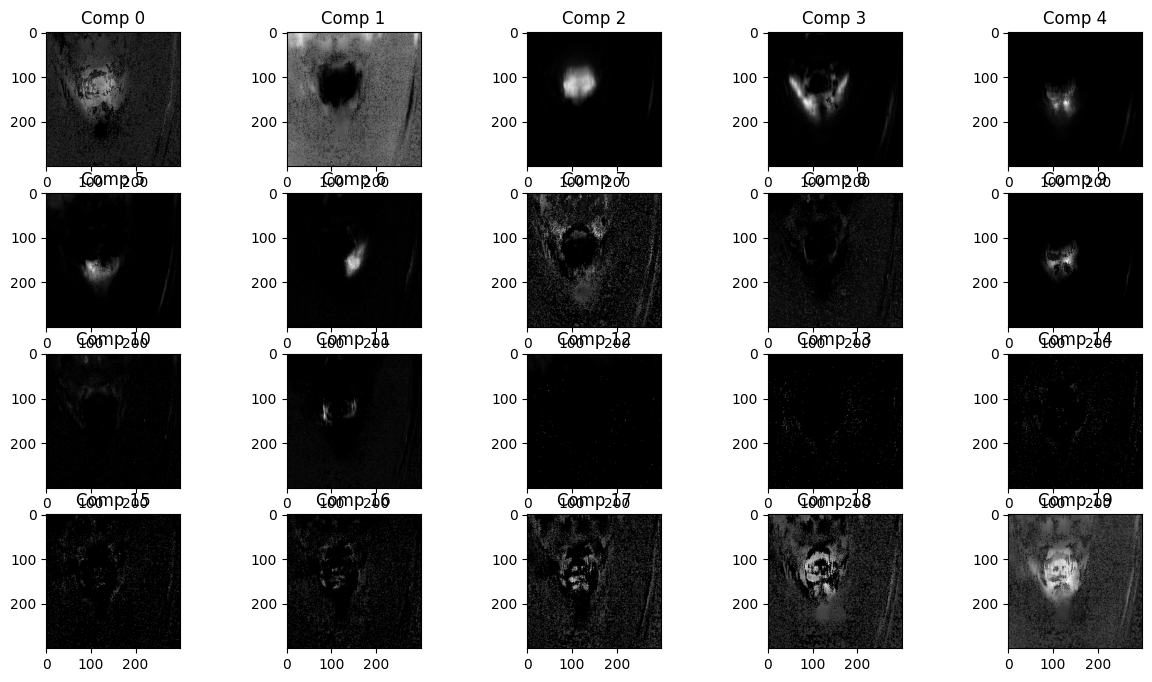

In [ ]:
# plot top components
num_components = K
fig, axes = plt.subplots(4, 5, figsize=(15, 8))
axes = axes.flatten()
for i in range(min(num_components, len(axes))):
    axes[i].imshow(W_2[i], cmap='gray')
    axes[i].set_title(f'Comp {i}')

# save figure
save_path = os.path.join(recording_path, f'MNF_spatial_comp_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

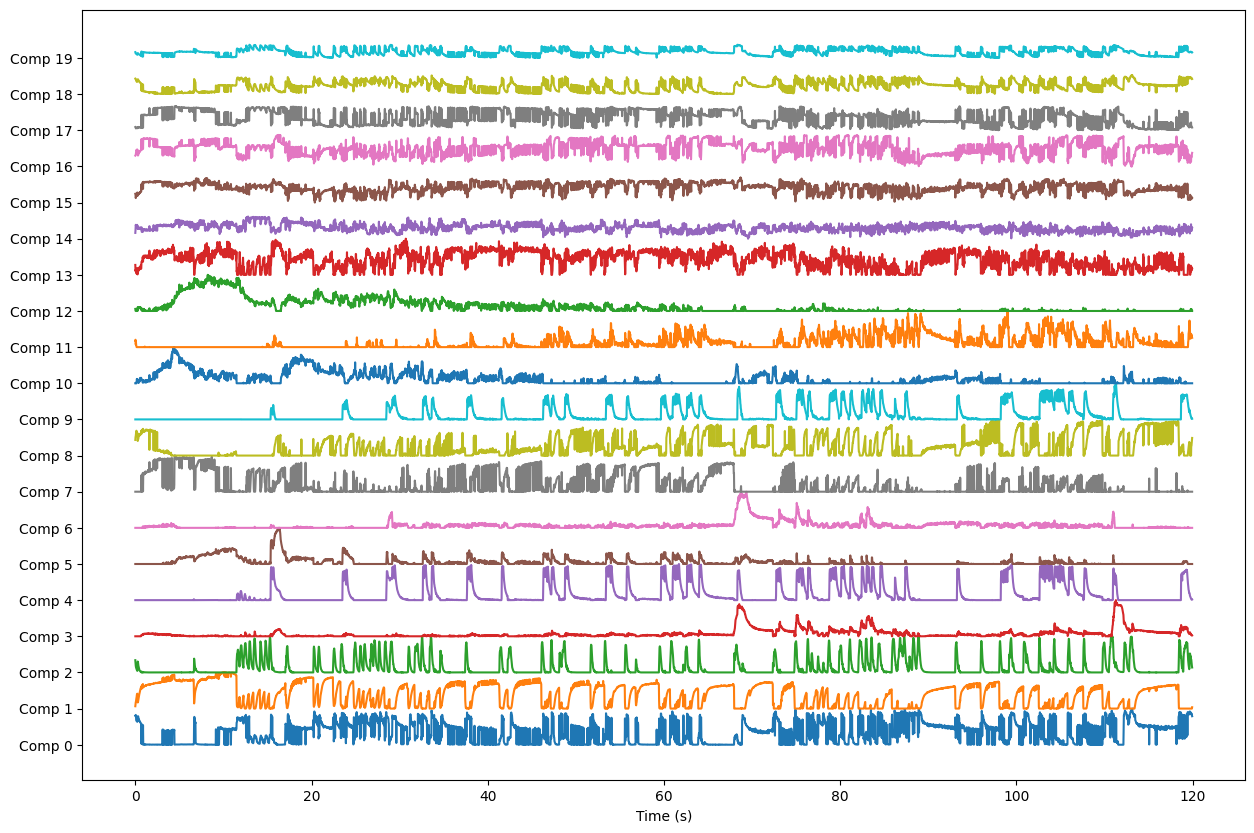

In [ ]:
# plot all components in time above each other
t = np.arange(H.shape[1])/hz
plt.figure(figsize=(15, 10))
for c in range(H.shape[0]):
    H_temp = (H[c] - np.min(H[c])) / np.max(H[c])
    plt.plot(t, H_temp + c*1)  # offset each component for visibility
plt.xlabel('Time (s)')
plt.yticks(range(H.shape[0]), [f'Comp {i}' for i in range(H.shape[0])])

save_path = os.path.join(recording_path, f'MNF_time_comp_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

In [ ]:
# Threshold & clean spatial maps
import scipy.ndimage as ndi

roi = np.zeros_like(W)
for r in range(roi.shape[1]):
    roi[:,r] = (W[:,r] > np.percentile(W[:,r], 98))

# recover shape
roi = roi.T.reshape(K, Y, X)

# plot top rois
num_components = K
fig, axes = plt.subplots(4, 5, figsize=(15, 8))
axes = axes.flatten()
for i in range(min(num_components, len(axes))):
    axes[i].imshow(roi[i], cmap='gray')
    axes[i].set_title(f'MNF ROI {i}')

# save figure
save_path = os.path.join(recording_path, f'MNF_rois_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()
